<a href="https://colab.research.google.com/github/arckra/Pengolahan-citra-1/blob/main/Pengolahan_Citra_Pertemuan1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Import Library

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Membaca dan Menampilkan Citra

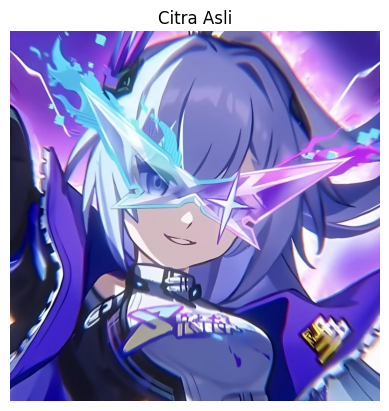

Ukuran citra (baris, kolom, channel): (736, 736, 3)


In [ ]:
# membaca citra
img = cv2.imread('sw.jpg')

# Memeriksa apakah citra berhasil dimuat
if img is None:
    print("Error: Tidak dapat memuat citra. Pastikan 'gambar.jpg' ada di direktori yang benar.")
else:
    # konversi BGR ke RGB (agar warna benar di matplotlib)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img_rgb)
    plt.title("Citra Asli")
    plt.axis('off')
    plt.show()

    print("Ukuran citra (baris, kolom, channel):", img.shape)

#Digitalisasi Spasial (Sampling / Resolusi)

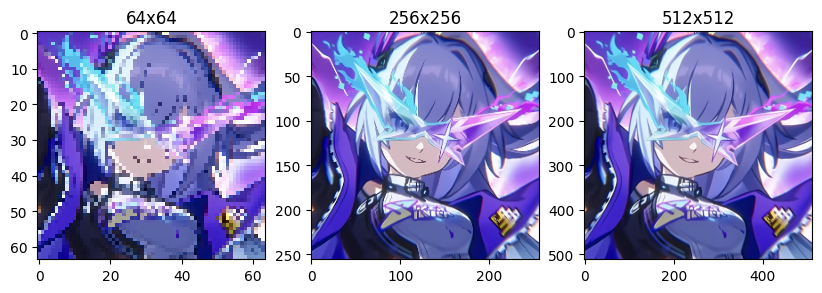

In [ ]:
# simulasi perubahan resolusi
small = cv2.resize(img_rgb, (64, 64))
medium = cv2.resize(img_rgb, (256, 256))
large = cv2.resize(img_rgb, (512, 512))

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(small)
plt.title("64x64")

plt.subplot(1,3,2)
plt.imshow(medium)
plt.title("256x256")

plt.subplot(1,3,3)
plt.imshow(large)
plt.title("512x512")

plt.show()

#Digitalisasi Intensitas (Kuantisasi)

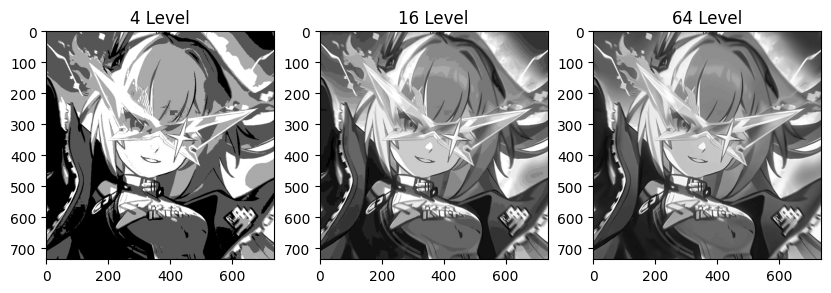

In [ ]:
# konversi ke grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# fungsi kuantisasi
def quantization(image, level):
    step = 256 // level
    quantized = (image // step) * step
    return quantized

q4 = quantization(gray, 4)
q16 = quantization(gray, 16)
q64 = quantization(gray, 64)

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.imshow(q4, cmap='gray')
plt.title("4 Level")

plt.subplot(1,3,2)
plt.imshow(q16, cmap='gray')
plt.title("16 Level")

plt.subplot(1,3,3)
plt.imshow(q64, cmap='gray')
plt.title("64 Level")

plt.show()

semakin besar derajat keabuan maka kualitas citra semakin baik

#Jenis Citra (Biner, Grayscale, RGB)

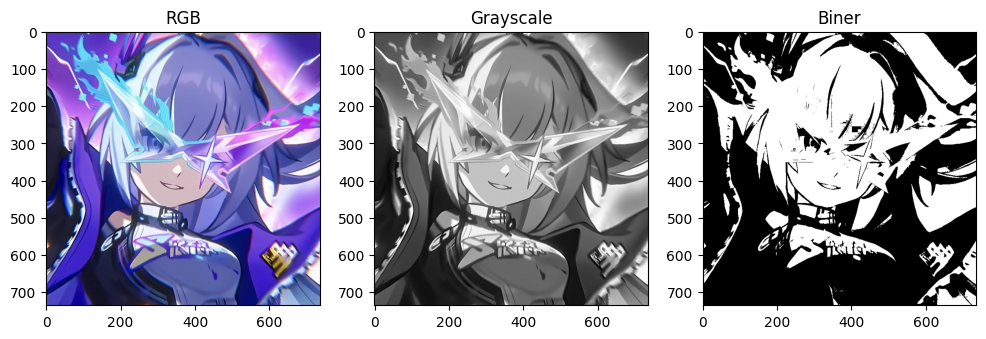

In [ ]:
# citra biner
_, binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(img_rgb)
plt.title("RGB")

plt.subplot(1,3,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")

plt.subplot(1,3,3)
plt.imshow(binary, cmap='gray')
plt.title("Biner")

plt.show()

	RGB : 3 kanal
	Grayscale : 1 kanal
	Biner : 0 dan 1

#Representasi Matriks Citra

In [ ]:
print("Sebagian matriks citra grayscale:")
print(gray[0:10, 0:10])

Sebagian matriks citra grayscale:
[[155 156 159 159 159 160 161 160 161 163]
 [156 157 159 158 159 162 161 161 161 164]
 [157 156 159 159 160 161 162 162 162 163]
 [159 159 160 160 160 162 162 163 163 165]
 [160 160 160 161 161 162 162 163 162 165]
 [161 161 161 162 162 161 164 165 164 167]
 [164 164 162 162 162 164 164 165 165 167]
 [164 164 164 164 164 165 165 165 165 166]
 [165 165 166 166 166 165 165 165 165 167]
 [165 166 166 166 165 166 166 166 165 166]]


#Perhitungan Memori Citra

In [ ]:
def hitung_memori(width, height, bit_depth):
    memory_bit = width * height * bit_depth
    memory_byte = memory_bit / 8
    return memory_bit, memory_byte

w, h, bit = 200, 100, 8

bit_size, byte_size = hitung_memori(w, h, bit)

print("Memori (bit):", bit_size)
print("Memori (byte):", byte_size)

Memori (bit): 160000
Memori (byte): 20000.0


#Eksperimen DPI Scanner (Simulasi)

In [ ]:
def ukuran_citra(inch_w, inch_h, dpi):
    pixel = inch_w * inch_h * (dpi**2)
    ukuran_byte = pixel * 3   # RGB = 3 byte
    return pixel, ukuran_byte

p100, s100 = ukuran_citra(3,4,100)
p500, s500 = ukuran_citra(3,4,500)

print("Scanner 100 DPI:", s100/1024, "KB")
print("Scanner 500 DPI:", s500/1024, "KB")

Scanner 100 DPI: 351.5625 KB
Scanner 500 DPI: 8789.0625 KB
